In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

In [8]:
tech= pd.read_csv(r"E:\Dowloads\indian_tech_jobs_2026.csv")

In [9]:
print(tech)

       job_id                                        job_title  \
0           1                                   Data Scientist   
1           2                                   Data Scientist   
2           3                         Analytics Data Scientist   
3           4                                   Data Scientist   
4           5             Sr. Artificial Intelligence Engineer   
...       ...                                              ...   
23196   23197                       Python Developer-Hyderabad   
23197   23198                                 Python Developer   
23198   23199  Walk in Interview Python Developer II Hyderabad   
23199   23200                                 Python Developer   
23200   23201                                 Python Developer   

                          company_name  company_rating  \
0                                Cisco             4.1   
1                      Caterpillar Inc             4.1   
2            Foreign IT Consultin

In [10]:
tech.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [11]:
tech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  object 
 2   company_name         23201 non-null  object 
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  object 
 5   scraped_city         23201 non-null  object 
 6   role_category        23201 non-null  object 
 7   experience_raw       23201 non-null  object 
 8   experience_min_yrs   23201 non-null  float64
 9   experience_max_yrs   23201 non-null  float64
 10  salary_raw           23201 non-null  object 
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  object 
 15  skills_count         23201 non-null 

In [12]:
tech.isnull().sum()

job_id                  0
job_title               0
company_name            0
company_rating          0
location                0
scraped_city            0
role_category           0
experience_raw          0
experience_min_yrs      0
experience_max_yrs      0
salary_raw              0
salary_min_lpa          0
salary_max_lpa          0
salary_disclosed        0
skills_required         0
skills_count            0
job_description         0
posted_date_raw         0
work_mode               0
company_size_bucket     0
job_url                53
data_source             0
scraped_at              0
salary_tier             0
experience_tier         0
is_senior               0
primary_city            0
skill_domain            0
salary_midpoint_lpa     0
days_since_posted       0
is_fresher_friendly     0
salary_negotiable       0
dtype: int64

In [15]:
tech['job_url'] = tech['job_url'].fillna(0)

In [16]:
tech.isnull().sum()

job_id                 0
job_title              0
company_name           0
company_rating         0
location               0
scraped_city           0
role_category          0
experience_raw         0
experience_min_yrs     0
experience_max_yrs     0
salary_raw             0
salary_min_lpa         0
salary_max_lpa         0
salary_disclosed       0
skills_required        0
skills_count           0
job_description        0
posted_date_raw        0
work_mode              0
company_size_bucket    0
job_url                0
data_source            0
scraped_at             0
salary_tier            0
experience_tier        0
is_senior              0
primary_city           0
skill_domain           0
salary_midpoint_lpa    0
days_since_posted      0
is_fresher_friendly    0
salary_negotiable      0
dtype: int64

In [24]:
tech.groupby(["primary_city", "role_category"])["job_id"] \
  .count() \
  .unstack(fill_value=0)

role_category,Business Analyst,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Python Developer
primary_city,,,,,,
Agra,1,0,0,0,0,0
Ahemdabad,0,0,1,0,0,0
Ahmedabad,215,532,66,305,234,0
Ahmedabad(Ahmedabad Cantonment),0,1,0,0,0,0
Ahmedabad(Ambli Bopal),0,1,0,0,0,0
...,...,...,...,...,...,...
Temp. Wfh - Kolkata,0,0,0,0,1,0
Temp. Wfh - Pune,0,0,0,0,1,0
Udaipur,2,0,0,0,0,0


In [26]:

# Clean job_url
tech["job_url"] = tech["job_url"].fillna("Not Available")

# Basic text cleanup
text_cols = ["role_category", "primary_city", "experience_tier", "skills_required"]

for col in text_cols:
    tech[col] = tech[col].astype(str).str.strip()

In [27]:
# Convert skills_required into clean skill lists

def clean_skill_list(skill_text):
    if pd.isna(skill_text):
        return []

    skill_text = str(skill_text)
    
    # Remove common list characters if present
    for ch in ["[", "]", "'", '"']:
        skill_text = skill_text.replace(ch, "")
    
    skills = skill_text.split(",")
    skills = [skill.strip().lower() for skill in skills]
    skills = [skill for skill in skills if skill not in ["", "nan", "none"]]
    
    return skills

tech["skill_list"] = tech["skills_required"].apply(clean_skill_list)
tech["clean_skills_count"] = tech["skill_list"].apply(len)

tech[["role_category", "primary_city", "experience_tier", "skills_required", "skill_list"]].head()

,role_category,primary_city,experience_tier,skills_required,skill_list
0,Data Scientist,Bangalore,Senior (6-8 Yrs),"Computer science, Data analysis, data science,...","[computer science, data analysis, data science..."
1,Data Scientist,Bangalore,Mid (3-5 Yrs),"Basic, Data management, Business analytics, An...","[basic, data management, business analytics, a..."
2,Data Scientist,Hyderabad,Mid (3-5 Yrs),Not Available,[not available]
3,Data Scientist,Mumbai,Fresher,Not Available,[not available]
4,Data Scientist,Pune,Mid (3-5 Yrs),Not Available,[not available]


In [28]:
# Create exploded skill-level dataframe

skills_df = tech.explode("skill_list").rename(columns={"skill_list": "skill"})
skills_df = skills_df[skills_df["skill"].notna()]
skills_df = skills_df[skills_df["skill"] != ""]

skills_df.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable,skill,clean_skills_count
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False,computer science,8
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False,data analysis,8
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False,data science,8
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False,supply chain operations,8
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False,data visualization,8


In [29]:
### Phase 1: Role Based skill Roadmap
def role_skill_roadmap(role, top_n=15):
    role_data = skills_df[
        skills_df["role_category"].str.lower() == role.lower()
    ]

    if role_data.empty:
        print(f"No data found for role: {role}")
        return None

    roadmap = (
        role_data
        .groupby(["experience_tier", "skill"])
        .agg(
            demand_count=("job_id", "count"),
            avg_salary_lpa=("salary_midpoint_lpa", "mean"),
            avg_min_exp=("experience_min_yrs", "mean")
        )
        .reset_index()
        .sort_values(["experience_tier", "demand_count"], ascending=[True, False])
    )

    top_roadmap = (
        roadmap
        .groupby("experience_tier")
        .head(top_n)
        .reset_index(drop=True)
    )

    return top_roadmap

In [30]:
roadmap = role_skill_roadmap("Data Scientist", top_n=10)
roadmap

,experience_tier,skill,demand_count,avg_salary_lpa,avg_min_exp
0,Fresher,machine learning,123,0.658537,0.000000
1,Fresher,python,97,3.220206,0.000000
2,Fresher,data analysis,86,0.622093,0.000000
3,Fresher,sql,77,1.714156,0.000000
4,Fresher,analytical,63,0.000000,0.000000
5,Fresher,data science,58,2.521552,0.000000
6,Fresher,computer science,51,0.000000,0.000000
7,Fresher,analytics,48,0.288958,0.000000
8,Fresher,automation,46,0.000000,0.000000
9,Fresher,data,46,3.459130,0.000000


In [31]:
def plot_role_roadmap(role, top_n=10):
    roadmap = role_skill_roadmap(role, top_n)

    if roadmap is None:
        return

    plt.figure(figsize=(14, 7))

    sns.barplot(
        data=roadmap,
        x="demand_count",
        y="skill",
        hue="experience_tier"
    )

    plt.title(f"Skill Roadmap for {role}")
    plt.xlabel("Number of Job Postings")
    plt.ylabel("Skill")
    plt.legend(title="Experience Tier")
    plt.tight_layout()
    plt.show()

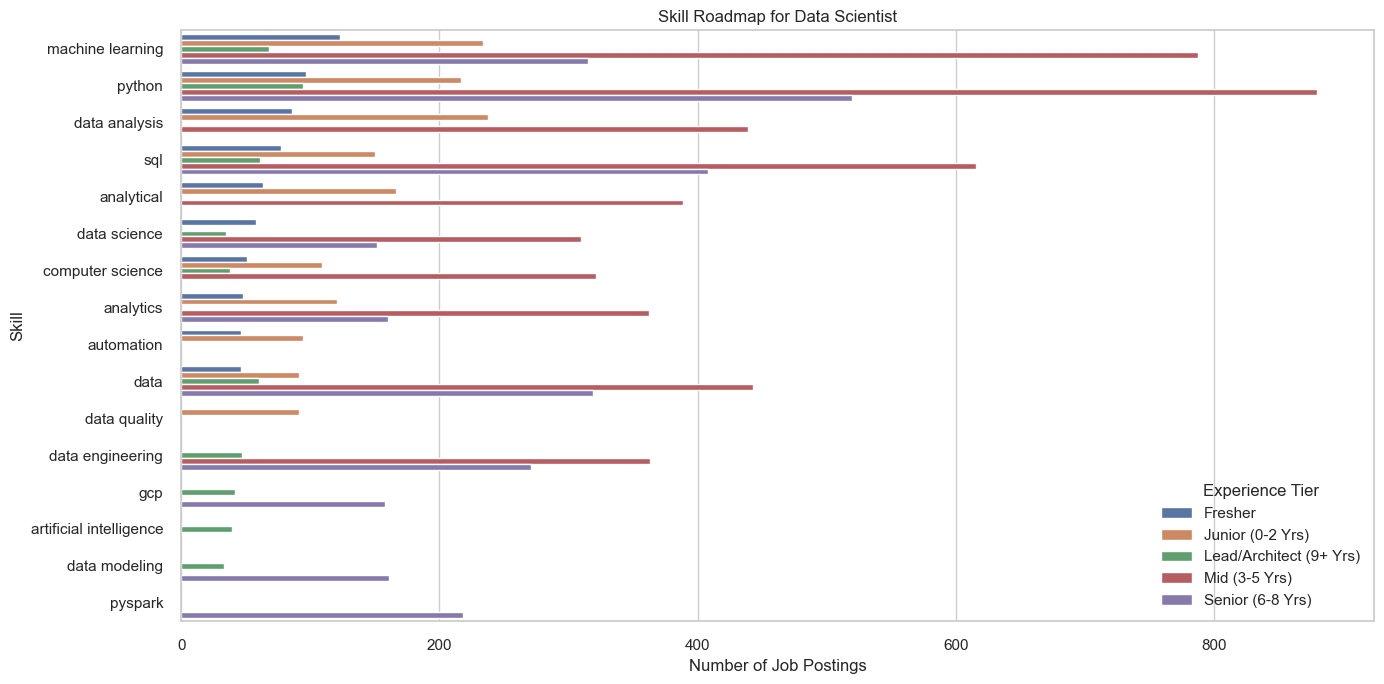

In [32]:
plot_role_roadmap("Data Scientist", top_n=10)

In [33]:
def high_salary_skills_for_role(role, min_demand=10, top_n=15):
    role_data = skills_df[
        skills_df["role_category"].str.lower() == role.lower()
    ]

    result = (
        role_data
        .groupby("skill")
        .agg(
            demand_count=("job_id", "count"),
            avg_salary_lpa=("salary_midpoint_lpa", "mean")
        )
        .reset_index()
    )

    result = result[result["demand_count"] >= min_demand]
    result = result.sort_values("avg_salary_lpa", ascending=False)

    return result.head(top_n)

In [34]:
high_salary_skills_for_role("Data Scientist", min_demand=10, top_n=15)

,skill,demand_count,avg_salary_lpa
1109,decision tree,14,18.214286
1475,fraud detection,13,12.961538
2192,mlops,43,11.116279
38,adf,19,11.078947
1187,dl,10,10.900000
970,data ingestion,11,10.863636
77,agentic ai,85,10.635294
1532,genai,22,10.590909
2011,logistic regression,43,10.569767
2087,master data management,13,10.480769


In [35]:
### Phase 2: Skill Co-occurrence Analysis

# Create skill pair counts

pair_counter = Counter()

for skills in tech["skill_list"]:
    unique_skills = sorted(set(skills))
    
    for skill_a, skill_b in combinations(unique_skills, 2):
        pair_counter[(skill_a, skill_b)] += 1

skill_edges = pd.DataFrame(
    [
        {"skill_1": pair[0], "skill_2": pair[1], "weight": count}
        for pair, count in pair_counter.items()
    ]
)

skill_edges = skill_edges.sort_values("weight", ascending=False)

skill_edges.head(20)

,skill_1,skill_2,weight
78,machine learning,python,1192
240,python,sql,1140
398,artificial intelligence,machine learning,965
268,analytical,data analysis,778
219,artificial intelligence,python,732
327,machine learning,natural language processing,635
11176,business analysis,project management,619
225,data,python,609
73,data science,machine learning,601
142,computer science,machine learning,584


In [36]:
import networkx as nx

def plot_skill_network(top_n_edges=50):
    top_edges = skill_edges.head(top_n_edges)

    G = nx.Graph()

    for _, row in top_edges.iterrows():
        G.add_edge(row["skill_1"], row["skill_2"], weight=row["weight"])

    plt.figure(figsize=(14, 10))

    pos = nx.spring_layout(G, k=0.6, seed=42)

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    node_sizes = [G.degree(node) * 250 for node in G.nodes()]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color="#4C78A8",
        alpha=0.85
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=[w / max(edge_weights) * 5 for w in edge_weights],
        alpha=0.35
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=9,
        font_color="black"
    )

    plt.title(f"Top {top_n_edges} Skill Co-occurrence Network")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

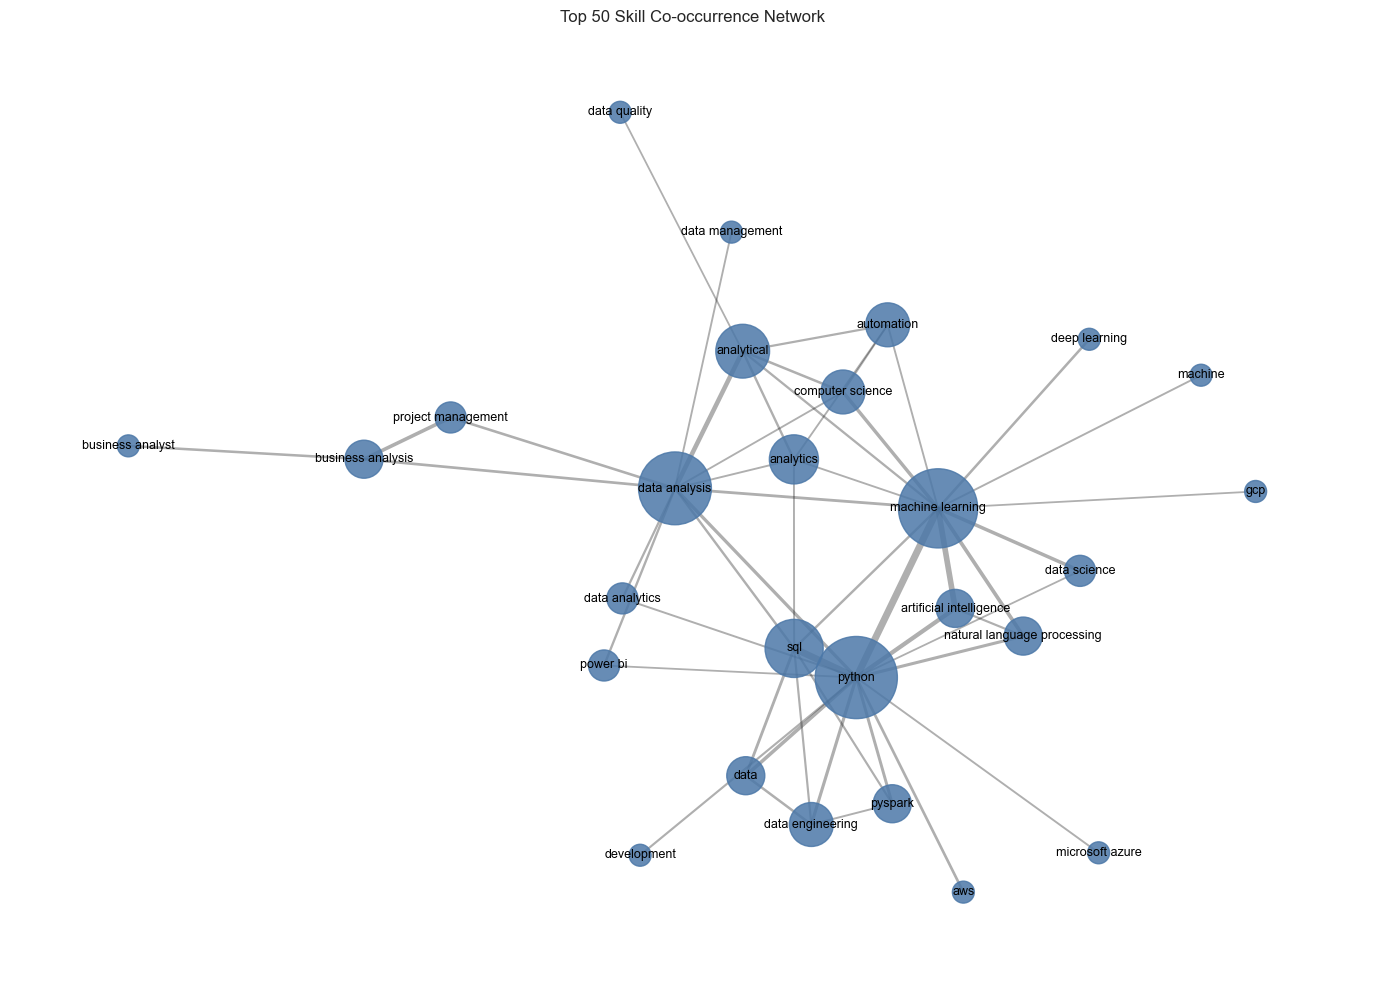

In [37]:
plot_skill_network(top_n_edges=50)

In [38]:
### Phase 3: City x Skill heat map

def city_skill_heatmap(top_n_skills=20, top_n_cities=10, normalize=True):
    top_skills = (
        skills_df["skill"]
        .value_counts()
        .head(top_n_skills)
        .index
    )

    top_cities = (
        skills_df["primary_city"]
        .value_counts()
        .head(top_n_cities)
        .index
    )

    filtered = skills_df[
        skills_df["skill"].isin(top_skills)
        & skills_df["primary_city"].isin(top_cities)
    ]

    heatmap_data = pd.crosstab(
        filtered["primary_city"],
        filtered["skill"]
    )

    if normalize:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(16, 8))

    sns.heatmap(
        heatmap_data,
        cmap="YlGnBu",
        annot=True,
        fmt=".1f" if normalize else "d"
    )

    title_type = "Percentage Demand" if normalize else "Job Count"
    plt.title(f"City x Skill Heat Map ({title_type})")
    plt.xlabel("Skill")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()

    return heatmap_data

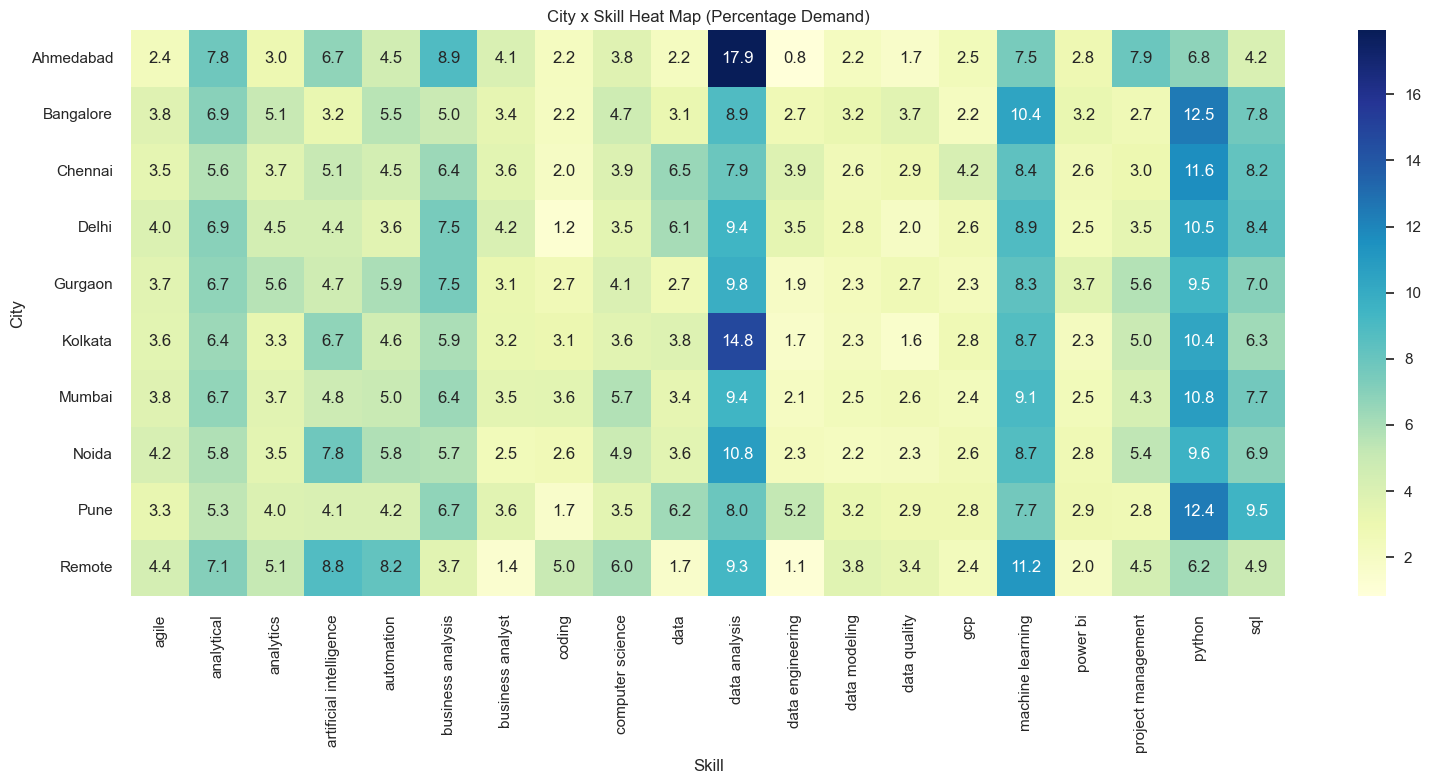

skill,agile,analytical,analytics,artificial intelligence,automation,business analysis,business analyst,coding,computer science,data,data analysis,data engineering,data modeling,data quality,gcp,machine learning,power bi,project management,python,sql
primary_city,,,,,,,,,,,,,,,,,,,,
Ahmedabad,2.405686,7.818480,2.952433,6.724986,4.537999,8.857299,4.100601,2.186987,3.827228,2.186987,17.933297,0.820120,2.186987,1.694915,2.515036,7.490432,2.843084,7.927829,6.834336,4.155276
Bangalore,3.803373,6.925009,5.059203,3.193398,5.507714,4.951561,3.426624,2.152853,4.718335,3.121636,8.898457,2.709006,3.157517,3.659849,2.170793,10.387513,3.175457,2.709006,12.504485,7.768210
Chennai,3.489573,5.637002,3.716705,5.079496,4.460045,6.421639,3.572166,1.961594,3.943836,6.462936,7.928970,3.881891,2.601693,2.890770,4.191617,8.362585,2.581045,2.994012,11.583729,8.238695
Delhi,3.986524,6.906232,4.491859,4.435710,3.649635,7.467715,4.154969,1.235261,3.537339,6.064009,9.376755,3.481190,2.751263,2.021336,2.638967,8.871421,2.526670,3.481190,10.499719,8.422235
Gurgaon,3.667546,6.728232,5.593668,4.696570,5.910290,7.467018,3.113456,2.664908,4.089710,2.744063,9.815303,1.926121,2.321900,2.717678,2.295515,8.337731,3.746702,5.646438,9.498681,7.018470
Kolkata,3.589109,6.394389,3.300330,6.724422,4.620462,5.940594,3.217822,3.052805,3.630363,3.836634,14.768977,1.691419,2.268977,1.608911,2.764026,8.745875,2.268977,4.950495,10.354785,6.270627
Mumbai,3.810094,6.662677,3.670457,4.807500,4.987034,6.423299,3.530820,3.610612,5.745063,3.391183,9.415520,2.074606,2.473569,2.593258,2.413724,9.056453,2.493517,4.328745,10.831837,7.680032
Noida,4.170051,5.821825,3.520173,7.798538,5.794747,5.686434,2.545356,2.626591,4.874086,3.574330,10.804224,2.301652,2.220417,2.274574,2.626591,8.746277,2.789060,5.361495,9.612781,6.850799
Pune,3.283340,5.310093,4.012971,4.114309,4.154844,6.728820,3.648156,1.682205,3.546818,6.242400,7.965140,5.168221,3.202270,2.857722,2.837454,7.701662,2.857722,2.776652,12.423997,9.485205


In [39]:
city_skill_matrix = city_skill_heatmap(
    top_n_skills=20,
    top_n_cities=10,
    normalize=True
)

city_skill_matrix

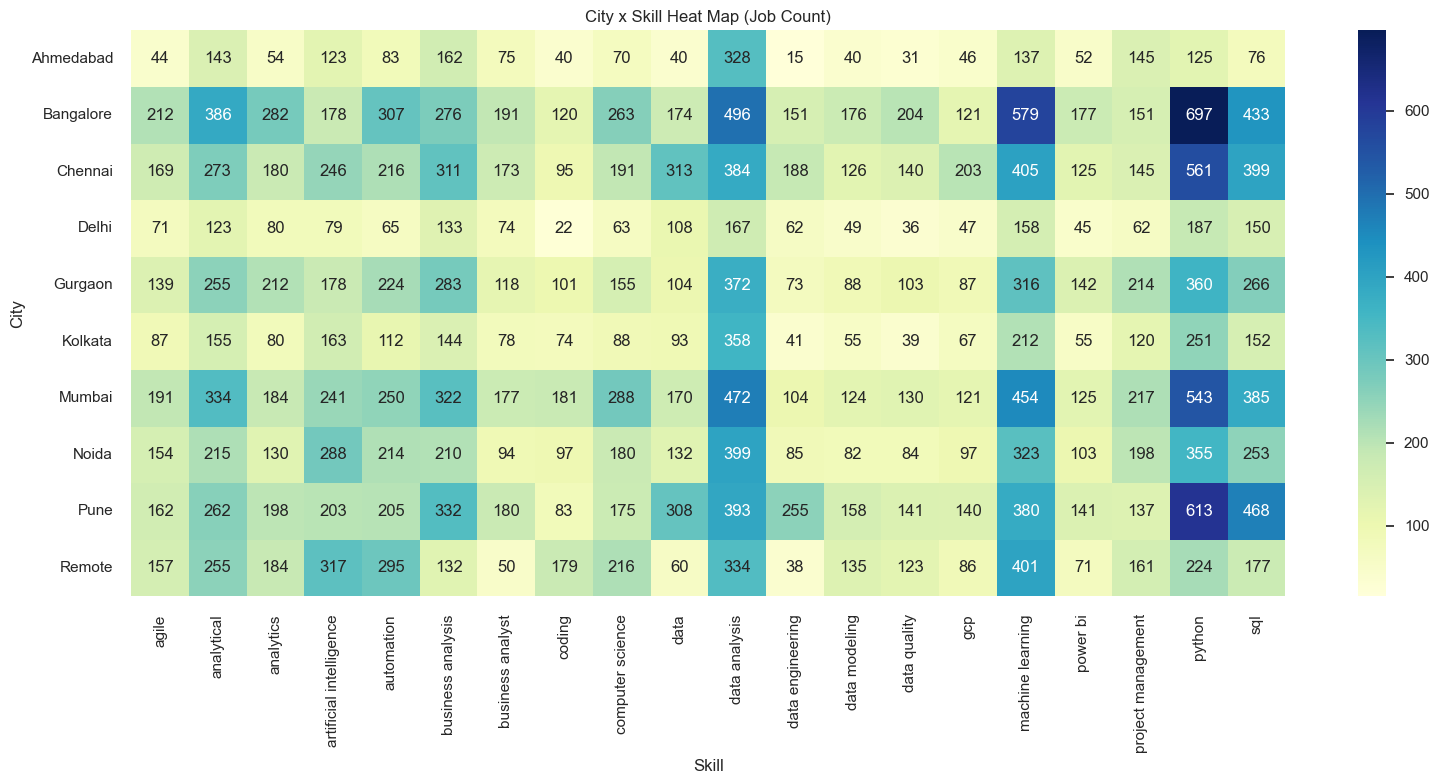

skill,agile,analytical,analytics,artificial intelligence,automation,business analysis,business analyst,coding,computer science,data,data analysis,data engineering,data modeling,data quality,gcp,machine learning,power bi,project management,python,sql
primary_city,,,,,,,,,,,,,,,,,,,,
Ahmedabad,44,143,54,123,83,162,75,40,70,40,328,15,40,31,46,137,52,145,125,76
Bangalore,212,386,282,178,307,276,191,120,263,174,496,151,176,204,121,579,177,151,697,433
Chennai,169,273,180,246,216,311,173,95,191,313,384,188,126,140,203,405,125,145,561,399
Delhi,71,123,80,79,65,133,74,22,63,108,167,62,49,36,47,158,45,62,187,150
Gurgaon,139,255,212,178,224,283,118,101,155,104,372,73,88,103,87,316,142,214,360,266
Kolkata,87,155,80,163,112,144,78,74,88,93,358,41,55,39,67,212,55,120,251,152
Mumbai,191,334,184,241,250,322,177,181,288,170,472,104,124,130,121,454,125,217,543,385
Noida,154,215,130,288,214,210,94,97,180,132,399,85,82,84,97,323,103,198,355,253
Pune,162,262,198,203,205,332,180,83,175,308,393,255,158,141,140,380,141,137,613,468


In [40]:
# Job-count version
city_skill_heatmap(
    top_n_skills=20,
    top_n_cities=10,
    normalize=False
)

In [41]:
# Available roles
tech["role_category"].value_counts()

role_category
Data Scientist               6455
Data Analyst                 4729
Business Analyst             4505
Machine Learning Engineer    4004
Data Engineer                1922
Python Developer             1586
Name: count, dtype: int64

In [42]:
# Available cities
tech["primary_city"].value_counts()

primary_city
Mumbai                       3276
Bangalore                    2830
Chennai                      2666
Pune                         2606
Noida                        2585
                             ... 
Kolkata(Topsia)                 1
Chennai(Mogappair)              1
Chennai(Kattankulathur)         1
Chennai(Akkarai)                1
Mumbai(Aarey Milk Colony)       1
Name: count, Length: 198, dtype: int64

In [43]:
# Top skills overall
skills_df["skill"].value_counts().head(30)


skill
python                         4266
data analysis                  3776
machine learning               3520
sql                            2940
analytical                     2427
business analysis              2396
artificial intelligence        2137
automation                     1995
computer science               1699
data                           1654
analytics                      1636
project management             1573
agile                          1401
business analyst               1251
data engineering               1118
power bi                       1094
gcp                            1061
data modeling                  1057
data quality                   1041
coding                          999
data science                    965
data management                 910
aws                             883
natural language processing     876
pyspark                         870
javascript                      852
cloud                           849
consulting            

In [44]:
# Top skills by role
(
    skills_df
    .groupby(["role_category", "skill"])
    .size()
    .reset_index(name="demand_count")
    .sort_values(["role_category", "demand_count"], ascending=[True, False])
    .groupby("role_category")
    .head(10)
)

,role_category,skill,demand_count
486,Business Analyst,business analysis,1681
491,Business Analyst,business analyst,925
3092,Business Analyst,project management,720
169,Business Analyst,analytical,555
98,Business Analyst,agile,468
295,Business Analyst,automation,381
3884,Business Analyst,sql,263
882,Business Analyst,consulting,246
2354,Business Analyst,management,225
176,Business Analyst,analytics,223
